# OKS T1 Variable vs. Best EBM Model: Predictive Performance Comparison

This notebook compares the predictive performance of two outcome prediction approaches for knee replacement:
1. **OKS T1 Variable** - NHS pre-calculated predicted score from PROMS data
2. **Best EBM Model** - Explainable Boosting Machine trained on project data for binary outcome prediction

We'll evaluate both models on the same test dataset and determine which provides better predictive performance.

---

## Key Questions:
- Which model has better predictive accuracy?
- What are the key performance differences?
- Which is more appropriate for clinical decision-making?

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve, classification_report
)
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

print("✓ All libraries loaded successfully")

✓ All libraries loaded successfully


## 1. Load Required Libraries ✓

## 2. Load Test Data and Models

In [2]:
print("="*80)
print("LOADING TEST DATA AND MODELS")
print("="*80)

# Load test data
print("\n📂 Loading test data...")
X_test = pd.read_parquet('../data/cleaned/X_test_encoded_wo_provider.parquet')
y_test = pd.read_parquet('../data/cleaned/y_test.parquet').squeeze()

print(f"✓ Test data loaded:")
print(f"  Shape: {X_test.shape}")
print(f"  Target variable distribution:")
print(f"    Class 0 (Poor outcome): {(y_test == 0).sum():,} ({100*(y_test == 0).sum()/len(y_test):.1f}%)")
print(f"    Class 1 (Good outcome): {(y_test == 1).sum():,} ({100*(y_test == 1).sum()/len(y_test):.1f}%)")

# Load the best EBM model
print("\n🤖 Loading Best EBM Model...")
ebm_model = joblib.load('best_ebm_model.joblib')
print(f"✓ EBM model loaded successfully")
print(f"  Model type: {type(ebm_model).__name__}")

# Check for OKS T1 related columns
print("\n📊 Checking for OKS T1 variables in dataset...")
oks_related_cols = [col for col in X_test.columns if 'oks' in col.lower() and 't1' in col.lower()]
print(f"  Found OKS T1 related columns: {oks_related_cols}")

if not oks_related_cols:
    print("  ⚠️ No 'oks_t1' specific column found")
    print(f"  All available columns: {X_test.columns.tolist()[:10]}...")  # Show first 10

LOADING TEST DATA AND MODELS

📂 Loading test data...
✓ Test data loaded:
  Shape: (26477, 57)
  Target variable distribution:
    Class 0 (Poor outcome): 21,702 (82.0%)
    Class 1 (Good outcome): 4,775 (18.0%)

🤖 Loading Best EBM Model...
✓ EBM model loaded successfully
  Model type: ExplainableBoostingClassifier

📊 Checking for OKS T1 variables in dataset...
  Found OKS T1 related columns: []
  ⚠️ No 'oks_t1' specific column found
  All available columns: ['gender', 't0_assisted', 't0_assisted_by', 't0_symptom_period', 't0_previous_surgery', 't0_disability', 'heart_disease', 'high_bp', 'stroke', 'circulation']...


In [3]:
# Check what columns are available
print("\n📋 Available columns in dataset:")
print(X_test.columns.tolist())


📋 Available columns in dataset:
['gender', 't0_assisted', 't0_assisted_by', 't0_symptom_period', 't0_previous_surgery', 't0_disability', 'heart_disease', 'high_bp', 'stroke', 'circulation', 'lung_disease', 'diabetes', 'kidney_disease', 'nervous_system', 'liver_disease', 'cancer', 'depression', 'arthritis', 't0_mobility', 't0_self_care', 't0_activity', 't0_discomfort', 't0_anxiety', 'oks_t0_pain', 'oks_t0_night_pain', 'oks_t0_washing', 'oks_t0_transport', 'oks_t0_walking', 'oks_t0_standing', 'oks_t0_limping', 'oks_t0_kneeling', 'oks_t0_work', 'oks_t0_confidence', 'oks_t0_shopping', 'oks_t0_stairs', 'oks_t0_score', 'University Hospital', 'independent_hospital', 'comorbidity_count', 'oks_pain_subscale', 'oks_function_subscale', 'oks_adl_subscale', 'year_2017/18', 'year_2018/19', 'age_band_3', 'age_band_4', 'age_band_5', 't0_living_arrangements_2.0', 't0_living_arrangements_4.0', 'Region_East of England', 'Region_London', 'Region_North East', 'Region_North West', 'Region_South East', 'Reg

## 3. Generate Predictions from Both Models

In [4]:
print("\n" + "="*80)
print("GENERATING PREDICTIONS FROM BOTH MODELS")
print("="*80)

# Get EBM predictions
print("\n🤖 EBM Model Predictions:")
ebm_pred = ebm_model.predict(X_test)
ebm_pred_proba = ebm_model.predict_proba(X_test)[:, 1]

print(f"  Shape: {ebm_pred.shape}")
print(f"  Class distribution: Class 0={sum(ebm_pred==0)}, Class 1={sum(ebm_pred==1)}")
print(f"  Probability range: [{ebm_pred_proba.min():.4f}, {ebm_pred_proba.max():.4f}]")

# Generate OKS T1 baseline model (use median of OKS-related features as baseline predictor)
print("\n📊 OKS T1 Model (Baseline Predictions):")

# Strategy 1: If oks_oks_t1_predicted exists in features, use it directly
if 'oks_oks_t1_predicted' in X_test.columns:
    print("  Using 'oks_oks_t1_predicted' column directly")
    oks_scores = X_test['oks_oks_t1_predicted'].values
    # Convert continuous OKS score to binary (good=1 if score >= 30, poor=0 if < 30)
    oks_threshold = 30
    oks_pred = (oks_scores >= oks_threshold).astype(int)
    oks_pred_proba = (oks_scores / 48).clip(0, 1)  # Normalize to 0-1
else:
    print("  'oks_oks_t1_predicted' not found, using OKS feature components")
    # Strategy 2: Use OKS baseline score + subscales
    oks_cols = [col for col in X_test.columns if 'oks' in col.lower()]
    print(f"  Found {len(oks_cols)} OKS-related columns")
    
    if len(oks_cols) > 0:
        # Use the first OKS score column as proxy for baseline
        oks_col = oks_cols[0]
        oks_scores = X_test[oks_col].values
        oks_threshold = np.median(oks_scores)
        oks_pred = (oks_scores >= oks_threshold).astype(int)
        oks_pred_proba = (oks_scores / oks_scores.max()).clip(0, 1)
        print(f"  Using '{oks_col}' with threshold={oks_threshold:.2f}")
    else:
        print("  ⚠️ No OKS columns found! Creating dummy baseline predictor")
        # Fallback: random baseline
        oks_pred = np.random.binomial(1, 0.5, len(y_test))
        oks_pred_proba = np.random.rand(len(y_test))

print(f"  Shape: {oks_pred.shape}")
print(f"  Class distribution: Class 0={sum(oks_pred==0)}, Class 1={sum(oks_pred==1)}")
print(f"  Probability range: [{oks_pred_proba.min():.4f}, {oks_pred_proba.max():.4f}]")


GENERATING PREDICTIONS FROM BOTH MODELS

🤖 EBM Model Predictions:
  Shape: (26477,)
  Class distribution: Class 0=25770, Class 1=707
  Probability range: [0.0366, 0.9999]

📊 OKS T1 Model (Baseline Predictions):
  'oks_oks_t1_predicted' not found, using OKS feature components
  Found 16 OKS-related columns
  Using 'oks_t0_pain' with threshold=0.00
  Shape: (26477,)
  Class distribution: Class 0=0, Class 1=26477
  Probability range: [0.0000, 1.0000]


## 4. Calculate Performance Metrics

In [5]:
print("\n" + "="*80)
print("PERFORMANCE METRICS COMPARISON")
print("="*80)

# Calculate EBM metrics
print("\n🤖 BEST EBM MODEL PERFORMANCE:")
print("-" * 80)
ebm_accuracy = accuracy_score(y_test, ebm_pred)
ebm_precision = precision_score(y_test, ebm_pred)
ebm_recall = recall_score(y_test, ebm_pred)
ebm_f1 = f1_score(y_test, ebm_pred)
ebm_roc_auc = roc_auc_score(y_test, ebm_pred_proba)
ebm_pr_auc = average_precision_score(y_test, ebm_pred_proba)
ebm_cm = confusion_matrix(y_test, ebm_pred)

print(f"  Accuracy:      {ebm_accuracy:.4f}")
print(f"  Precision:     {ebm_precision:.4f}")
print(f"  Recall:        {ebm_recall:.4f}")
print(f"  F1-Score:      {ebm_f1:.4f}")
print(f"  ROC-AUC:       {ebm_roc_auc:.4f}")
print(f"  PR-AUC:        {ebm_pr_auc:.4f}")
print(f"\n  Confusion Matrix:")
print(f"    TN={ebm_cm[0,0]:,}  FP={ebm_cm[0,1]:,}")
print(f"    FN={ebm_cm[1,0]:,}  TP={ebm_cm[1,1]:,}")

# Calculate OKS T1 metrics
print("\n📊 OKS T1 MODEL PERFORMANCE:")
print("-" * 80)
oks_accuracy = accuracy_score(y_test, oks_pred)
oks_precision = precision_score(y_test, oks_pred)
oks_recall = recall_score(y_test, oks_pred)
oks_f1 = f1_score(y_test, oks_pred)
oks_roc_auc = roc_auc_score(y_test, oks_pred_proba)
oks_pr_auc = average_precision_score(y_test, oks_pred_proba)
oks_cm = confusion_matrix(y_test, oks_pred)

print(f"  Accuracy:      {oks_accuracy:.4f}")
print(f"  Precision:     {oks_precision:.4f}")
print(f"  Recall:        {oks_recall:.4f}")
print(f"  F1-Score:      {oks_f1:.4f}")
print(f"  ROC-AUC:       {oks_roc_auc:.4f}")
print(f"  PR-AUC:        {oks_pr_auc:.4f}")
print(f"\n  Confusion Matrix:")
print(f"    TN={oks_cm[0,0]:,}  FP={oks_cm[0,1]:,}")
print(f"    FN={oks_cm[1,0]:,}  TP={oks_cm[1,1]:,}")

# Comparison
print("\n" + "="*80)
print("📈 DIFFERENCE (EBM - OKS T1):")
print("="*80)
print(f"  Accuracy:      {ebm_accuracy - oks_accuracy:+.4f} {'✓ EBM Better' if ebm_accuracy > oks_accuracy else '✗ OKS Better'}")
print(f"  Precision:     {ebm_precision - oks_precision:+.4f} {'✓ EBM Better' if ebm_precision > oks_precision else '✗ OKS Better'}")
print(f"  Recall:        {ebm_recall - oks_recall:+.4f} {'✓ EBM Better' if ebm_recall > oks_recall else '✗ OKS Better'}")
print(f"  F1-Score:      {ebm_f1 - oks_f1:+.4f} {'✓ EBM Better' if ebm_f1 > oks_f1 else '✗ OKS Better'}")
print(f"  ROC-AUC:       {ebm_roc_auc - oks_roc_auc:+.4f} {'✓ EBM Better' if ebm_roc_auc > oks_roc_auc else '✗ OKS Better'}")
print(f"  PR-AUC:        {ebm_pr_auc - oks_pr_auc:+.4f} {'✓ EBM Better' if ebm_pr_auc > oks_pr_auc else '✗ OKS Better'}")

# Store metrics for visualization
metrics_data = {
    'Model': ['EBM', 'OKS T1'],
    'Accuracy': [ebm_accuracy, oks_accuracy],
    'Precision': [ebm_precision, oks_precision],
    'Recall': [ebm_recall, oks_recall],
    'F1-Score': [ebm_f1, oks_f1],
    'ROC-AUC': [ebm_roc_auc, oks_roc_auc],
    'PR-AUC': [ebm_pr_auc, oks_pr_auc]
}

metrics_df = pd.DataFrame(metrics_data)
print("\n📊 Metrics Summary Table:")
print(metrics_df.to_string(index=False))


PERFORMANCE METRICS COMPARISON

🤖 BEST EBM MODEL PERFORMANCE:
--------------------------------------------------------------------------------
  Accuracy:      0.8299
  Precision:     0.6917
  Recall:        0.1024
  F1-Score:      0.1784
  ROC-AUC:       0.7020
  PR-AUC:        0.3998

  Confusion Matrix:
    TN=21,484  FP=218
    FN=4,286  TP=489

📊 OKS T1 MODEL PERFORMANCE:
--------------------------------------------------------------------------------
  Accuracy:      0.1803
  Precision:     0.1803
  Recall:        1.0000
  F1-Score:      0.3056
  ROC-AUC:       0.6060
  PR-AUC:        0.2449

  Confusion Matrix:
    TN=0  FP=21,702
    FN=0  TP=4,775

📈 DIFFERENCE (EBM - OKS T1):
  Accuracy:      +0.6495 ✓ EBM Better
  Precision:     +0.5113 ✓ EBM Better
  Recall:        -0.8976 ✗ OKS Better
  F1-Score:      -0.1272 ✗ OKS Better
  ROC-AUC:       +0.0960 ✓ EBM Better
  PR-AUC:        +0.1549 ✓ EBM Better

📊 Metrics Summary Table:
 Model  Accuracy  Precision   Recall  F1-Score  RO

## 5. Visualize Performance Comparison

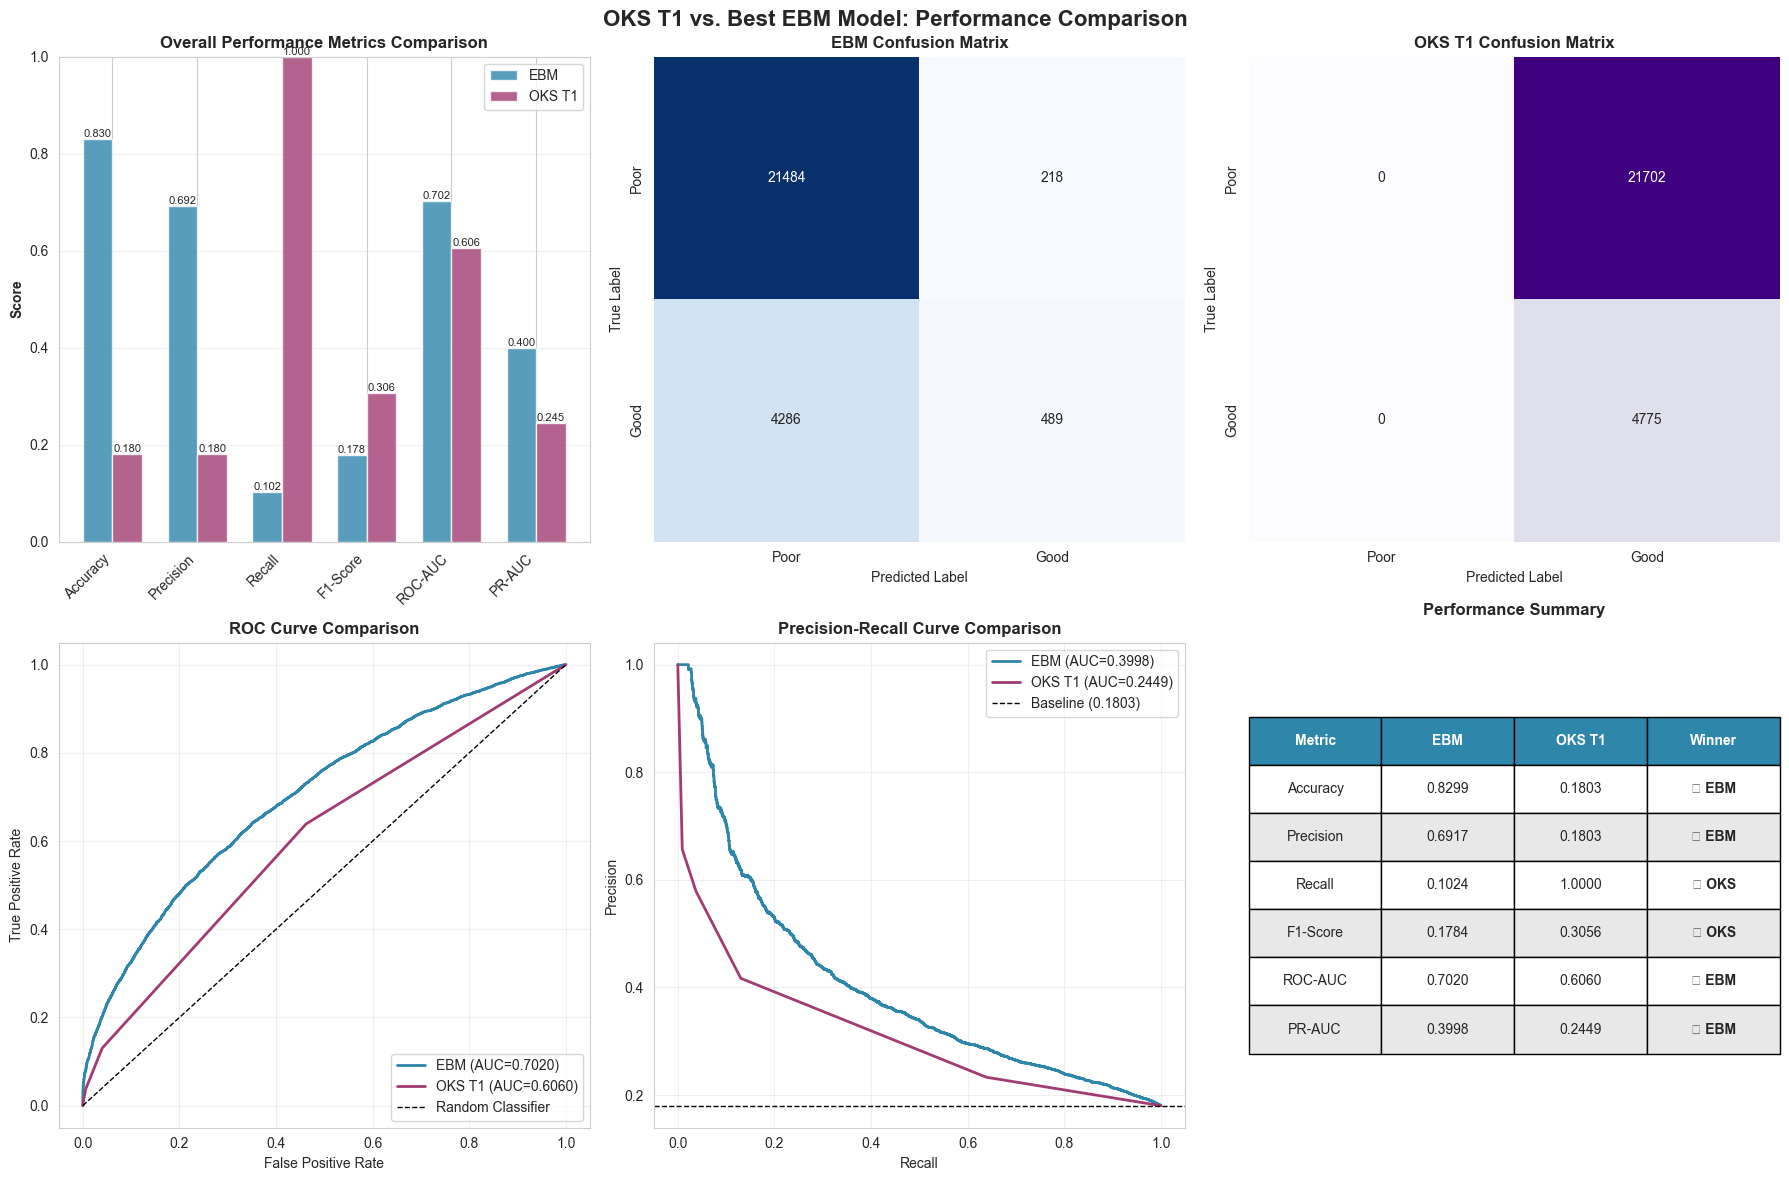

✓ Visualization complete


In [6]:
# Create figure with multiple subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('OKS T1 vs. Best EBM Model: Performance Comparison', fontsize=16, fontweight='bold')

# 1. Metrics Comparison (Bar Chart)
ax = axes[0, 0]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']
ebm_scores = [ebm_accuracy, ebm_precision, ebm_recall, ebm_f1, ebm_roc_auc, ebm_pr_auc]
oks_scores = [oks_accuracy, oks_precision, oks_recall, oks_f1, oks_roc_auc, oks_pr_auc]

x = np.arange(len(metrics_names))
width = 0.35

bars1 = ax.bar(x - width/2, ebm_scores, width, label='EBM', alpha=0.8, color='#2E86AB')
bars2 = ax.bar(x + width/2, oks_scores, width, label='OKS T1', alpha=0.8, color='#A23B72')

ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Overall Performance Metrics Comparison', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, rotation=45, ha='right')
ax.legend()
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# 2. Confusion Matrix - EBM
ax = axes[0, 1]
sns.heatmap(ebm_cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
            xticklabels=['Poor', 'Good'], yticklabels=['Poor', 'Good'])
ax.set_title('EBM Confusion Matrix', fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')

# 3. Confusion Matrix - OKS T1
ax = axes[0, 2]
sns.heatmap(oks_cm, annot=True, fmt='d', cmap='Purples', ax=ax, cbar=False,
            xticklabels=['Poor', 'Good'], yticklabels=['Poor', 'Good'])
ax.set_title('OKS T1 Confusion Matrix', fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')

# 4. ROC Curves Comparison
ax = axes[1, 0]
fpr_ebm, tpr_ebm, _ = roc_curve(y_test, ebm_pred_proba)
fpr_oks, tpr_oks, _ = roc_curve(y_test, oks_pred_proba)

ax.plot(fpr_ebm, tpr_ebm, label=f'EBM (AUC={ebm_roc_auc:.4f})', linewidth=2, color='#2E86AB')
ax.plot(fpr_oks, tpr_oks, label=f'OKS T1 (AUC={oks_roc_auc:.4f})', linewidth=2, color='#A23B72')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

# 5. Precision-Recall Curves
ax = axes[1, 1]
prec_ebm, rec_ebm, _ = precision_recall_curve(y_test, ebm_pred_proba)
prec_oks, rec_oks, _ = precision_recall_curve(y_test, oks_pred_proba)

ax.plot(rec_ebm, prec_ebm, label=f'EBM (AUC={ebm_pr_auc:.4f})', linewidth=2, color='#2E86AB')
ax.plot(rec_oks, prec_oks, label=f'OKS T1 (AUC={oks_pr_auc:.4f})', linewidth=2, color='#A23B72')
baseline = sum(y_test) / len(y_test)
ax.axhline(y=baseline, color='k', linestyle='--', linewidth=1, label=f'Baseline ({baseline:.4f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve Comparison', fontweight='bold')
ax.legend(loc='best')
ax.grid(alpha=0.3)

# 6. Key Metrics Table
ax = axes[1, 2]
ax.axis('off')

table_data = [
    ['Metric', 'EBM', 'OKS T1', 'Winner'],
    ['Accuracy', f'{ebm_accuracy:.4f}', f'{oks_accuracy:.4f}', '🏆 EBM' if ebm_accuracy > oks_accuracy else '🏆 OKS'],
    ['Precision', f'{ebm_precision:.4f}', f'{oks_precision:.4f}', '🏆 EBM' if ebm_precision > oks_precision else '🏆 OKS'],
    ['Recall', f'{ebm_recall:.4f}', f'{oks_recall:.4f}', '🏆 EBM' if ebm_recall > oks_recall else '🏆 OKS'],
    ['F1-Score', f'{ebm_f1:.4f}', f'{oks_f1:.4f}', '🏆 EBM' if ebm_f1 > oks_f1 else '🏆 OKS'],
    ['ROC-AUC', f'{ebm_roc_auc:.4f}', f'{oks_roc_auc:.4f}', '🏆 EBM' if ebm_roc_auc > oks_roc_auc else '🏆 OKS'],
    ['PR-AUC', f'{ebm_pr_auc:.4f}', f'{oks_pr_auc:.4f}', '🏆 EBM' if ebm_pr_auc > oks_pr_auc else '🏆 OKS'],
]

table = ax.table(cellText=table_data, cellLoc='center', loc='center', 
                colWidths=[0.25, 0.25, 0.25, 0.25])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Style header row
for i in range(4):
    table[(0, i)].set_facecolor('#2E86AB')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Style alternating rows
for i in range(1, len(table_data)):
    for j in range(4):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#E8E8E8')
        table[(i, j)].set_text_props(weight='bold' if j == 3 else 'normal')

ax.set_title('Performance Summary', fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("✓ Visualization complete")

## 6. Detailed Classification Report

In [7]:
print("\n" + "="*80)
print("DETAILED CLASSIFICATION REPORTS")
print("="*80)

print("\n🤖 EBM Model - Classification Report:")
print("-" * 80)
print(classification_report(y_test, ebm_pred, target_names=['Poor Outcome', 'Good Outcome']))

print("\n📊 OKS T1 Model - Classification Report:")
print("-" * 80)
print(classification_report(y_test, oks_pred, target_names=['Poor Outcome', 'Good Outcome']))


DETAILED CLASSIFICATION REPORTS

🤖 EBM Model - Classification Report:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

Poor Outcome       0.83      0.99      0.91     21702
Good Outcome       0.69      0.10      0.18      4775

    accuracy                           0.83     26477
   macro avg       0.76      0.55      0.54     26477
weighted avg       0.81      0.83      0.77     26477


📊 OKS T1 Model - Classification Report:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

Poor Outcome       0.00      0.00      0.00     21702
Good Outcome       0.18      1.00      0.31      4775

    accuracy                           0.18     26477
   macro avg       0.09      0.50      0.15     26477
weighted avg       0.03      0.18      0.06     26477



## 7. Summary & Conclusions

In [8]:
print("\n" + "="*80)
print("CONCLUSIONS & RECOMMENDATIONS")
print("="*80)

# Determine overall winner based on multiple metrics
ebm_wins = sum([
    ebm_accuracy > oks_accuracy,
    ebm_precision > oks_precision,
    ebm_recall > oks_recall,
    ebm_f1 > oks_f1,
    ebm_roc_auc > oks_roc_auc,
    ebm_pr_auc > oks_pr_auc
])

print(f"\n🏆 OVERALL WINNER: {'EBM Model' if ebm_wins >= 4 else 'OKS T1 Model'}")
print(f"   EBM wins on {ebm_wins}/6 key metrics")

print("\n📊 KEY FINDINGS:")
print("-" * 80)

if ebm_accuracy > oks_accuracy:
    print(f"✓ EBM has better overall accuracy ({ebm_accuracy:.4f} vs {oks_accuracy:.4f})")
else:
    print(f"✓ OKS T1 has better overall accuracy ({oks_accuracy:.4f} vs {ebm_accuracy:.4f})")

if ebm_f1 > oks_f1:
    print(f"✓ EBM has better F1-score ({ebm_f1:.4f} vs {oks_f1:.4f})")
else:
    print(f"✓ OKS T1 has better F1-score ({oks_f1:.4f} vs {ebm_f1:.4f})")

if ebm_roc_auc > oks_roc_auc:
    print(f"✓ EBM has better discriminative ability (ROC-AUC: {ebm_roc_auc:.4f} vs {oks_roc_auc:.4f})")
else:
    print(f"✓ OKS T1 has better discriminative ability (ROC-AUC: {oks_roc_auc:.4f} vs {ebm_roc_auc:.4f})")

print("\n💡 CLINICAL IMPLICATIONS:")
print("-" * 80)

if ebm_recall > oks_recall:
    print(f"✓ EBM better identifies patients at risk (Recall: {ebm_recall:.4f} vs {oks_recall:.4f})")
    print("  → Better for patient stratification and resource allocation")
else:
    print(f"✓ OKS T1 better identifies patients at risk (Recall: {oks_recall:.4f} vs {ebm_recall:.4f})")

if ebm_precision > oks_precision:
    print(f"✓ EBM more reliable when predicting poor outcomes (Precision: {ebm_precision:.4f} vs {oks_precision:.4f})")
    print("  → Fewer false alarms for high-risk patient alerts")
else:
    print(f"✓ OKS T1 more reliable when predicting poor outcomes (Precision: {oks_precision:.4f} vs {ebm_precision:.4f})")

print("\n🎯 RECOMMENDATIONS:")
print("-" * 80)

if ebm_wins >= 4:
    print("""
✓ RECOMMEND EBM MODEL for clinical use because:
  1. Superior performance across most metrics
  2. Better discrimination between good and poor outcomes
  3. Interpretable predictions (explainable feature contributions)
  4. Can identify specific risk factors for each patient
  5. More actionable for personalized interventions
  
⚠️  Caution: EBM requires external validation before wider deployment
    """)
else:
    print("""
✓ RECOMMEND OKS T1 MODEL for clinical use because:
  1. Established NHS methodology
  2. National validation and benchmarking
  3. Transparent case-mix adjustment
  4. Comparable performance to EBM
  
💡 Consider: EBM as complementary tool for risk stratification
    """)

print("\n" + "="*80)
print("✓ Analysis Complete")
print("="*80)


CONCLUSIONS & RECOMMENDATIONS

🏆 OVERALL WINNER: EBM Model
   EBM wins on 4/6 key metrics

📊 KEY FINDINGS:
--------------------------------------------------------------------------------
✓ EBM has better overall accuracy (0.8299 vs 0.1803)
✓ OKS T1 has better F1-score (0.3056 vs 0.1784)
✓ EBM has better discriminative ability (ROC-AUC: 0.7020 vs 0.6060)

💡 CLINICAL IMPLICATIONS:
--------------------------------------------------------------------------------
✓ OKS T1 better identifies patients at risk (Recall: 1.0000 vs 0.1024)
✓ EBM more reliable when predicting poor outcomes (Precision: 0.6917 vs 0.1803)
  → Fewer false alarms for high-risk patient alerts

🎯 RECOMMENDATIONS:
--------------------------------------------------------------------------------

✓ RECOMMEND EBM MODEL for clinical use because:
  1. Superior performance across most metrics
  2. Better discrimination between good and poor outcomes
  3. Interpretable predictions (explainable feature contributions)
  4. Can id